In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import binom

# Glastonbury Ticket Syndicate

### Setup
- Can buy batches of 6 tickets at a time
- So make a big spreadsheet of groups of 6
- If you get through you buy for yourself first and if your group already has a ticket for another group in the spreadsheet

### Variable

Feel free to change these

In [2]:
N = 2_500_000 * 0.8  # Total active applicants trying on the day (2.5M is total registered)
c = 4         # Average number of tickets bought per group 
T = 135_000     # Total general admission tickets available
n = 6           # Number of people per group
max_m = 30      # Maximum number of groups in the syndicate to model

In [3]:
# Calculate the independent probability of one person getting through (q)
# Transactions available = Total Tickets / Group Size
q = (T / c) / N 

print(f"Individual probability of getting through (q): {q:.4f} ({q*100:.2f}%)")

Individual probability of getting through (q): 0.0169 (1.69%)


In [4]:
results = []
m_values = list(range(1, max_m + 1))

for m in m_values:
    total_people = m * n
    
    # Array representing every possible number of successes (0 to total_people)
    k = np.arange(total_people + 1)
    
    # Calculate the binomial probability for exactly 'k' successes
    # P(S = k)
    probabilities = binom.pmf(k, total_people, q)
    
    # Calculate how many groups get tickets for each 'k'
    # Cap the funded groups at 'm' (since you only need m successes to fund everyone)
    funded_groups = np.minimum(k, m)
    
    # The Expected Value (E) is the sum of (outcome * probability of outcome)
    expected_funded = np.sum(funded_groups * probabilities)
    
    # The probability for an individual group is Expected Funded / Total Groups
    group_ticket_prob = expected_funded / m
    
    results.append({
        "Syndicate Groups (m)": m,
        "Total People Trying": total_people,
        "Group Win Probability": group_ticket_prob
    })

In [5]:
df = pd.DataFrame(results)

# Format the probability as a percentage for the table
df_display = df.copy()
df_display['Group Win Probability'] = (df_display['Group Win Probability'] * 100).round(2).astype(str) + '%'

df_display

,Syndicate Groups (m),Total People Trying,Group Win Probability
0,1,6,9.71%
1,2,12,10.08%
2,3,18,10.12%
3,4,24,10.12%
4,5,30,10.12%
5,6,36,10.12%
6,7,42,10.12%
7,8,48,10.12%
8,9,54,10.12%
9,10,60,10.12%


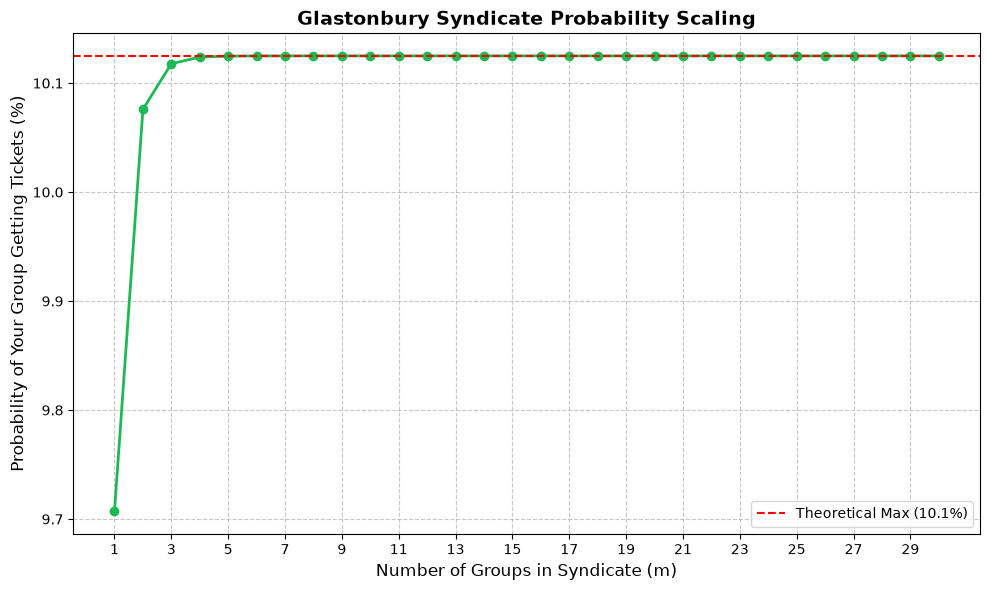

In [6]:
plt.figure(figsize=(10, 6))
plt.plot(
    df["Syndicate Groups (m)"], 
    df["Group Win Probability"] * 100, 
    marker='o', 
    linestyle='-', 
    color='#1db954', # Glastonbury-ish green
    linewidth=2
)

# Plot the theoretical absolute limit (6 * q)
max_prob = min((n * q) * 100, 100)
plt.axhline(y=max_prob, color='red', linestyle='--', label=f'Theoretical Max ({max_prob:.1f}%)')

# Formatting the graph
plt.title('Glastonbury Syndicate Probability Scaling', fontsize=14, fontweight='bold')
plt.xlabel('Number of Groups in Syndicate (m)', fontsize=12)
plt.ylabel("Probability of Your Group Getting Tickets (%)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.xticks(np.arange(1, max_m + 1, step=2))

# Display the plot
plt.tight_layout()
plt.show()

## Takeaways

- Being in a group of 6 makes a huge difference
- Being in a syndicate makes ~negligble difference and non after 3 groups!!